In [33]:
import pandas as pd

pair = 'BTCUSDT'
timeframe = '5m'
type_data = 'Futures'

# Importation des données


data = pd.read_csv(f'../data/binance/{pair}_{timeframe}_{type_data}.csv', parse_dates=[0], index_col=0)
data

,Open,High,Low,Close,Volume,Qav,Trades,Taker_base_vol,Taker_quote_vol
Date,,,,,,,,,
2019-09-08 21:35:00,10345.27,10347.09,10340.34,10341.14,56.122,5.805275e+05,65,0.000,0.000000e+00
2019-09-08 21:40:00,10341.14,10345.74,10337.43,10345.74,58.251,6.023933e+05,68,0.000,0.000000e+00
2019-09-08 21:45:00,10345.74,10345.74,10339.89,10344.04,56.087,5.801052e+05,67,0.000,0.000000e+00
2019-09-08 21:50:00,10344.04,10347.45,10341.46,10341.46,53.229,5.506463e+05,67,0.000,0.000000e+00
2019-09-08 21:55:00,10341.46,10343.21,10338.38,10340.12,54.179,5.602083e+05,64,0.000,0.000000e+00
...,...,...,...,...,...,...,...,...,...
2024-09-06 16:15:00,55075.50,55271.20,54890.90,55228.60,9300.777,5.121618e+08,93809,4811.244,2.650391e+08
2024-09-06 16:20:00,55228.50,55333.20,55026.40,55091.30,4156.872,2.295290e+08,50993,2189.174,1.209140e+08
2024-09-06 16:25:00,55091.30,55091.90,54691.80,54784.80,9184.692,5.037765e+08,79897,3226.039,1.769775e+08


In [37]:
fd = data['Close'].diff().abs()* 1000000/ data['Close'].shift(1)

print(fd)
fd = fd.dropna().astype(str).str[0].astype(int)
fd



Date
2019-09-08 21:35:00            NaN
2019-09-08 21:40:00     444.825232
2019-09-08 21:45:00     164.318840
2019-09-08 21:50:00     249.418989
2019-09-08 21:55:00     129.575514
                          ...     
2024-09-06 16:15:00    2779.820428
2024-09-06 16:20:00    2486.030788
2024-09-06 16:25:00    5563.491876
2024-09-06 16:30:00     532.994553
2024-09-06 16:35:00    2362.535119
Name: Close, Length: 525541, dtype: float64


Date
2019-09-08 21:40:00    4
2019-09-08 21:45:00    1
2019-09-08 21:50:00    2
2019-09-08 21:55:00    1
2019-09-08 22:00:00    5
                      ..
2024-09-06 16:15:00    2
2024-09-06 16:20:00    2
2024-09-06 16:25:00    5
2024-09-06 16:30:00    5
2024-09-06 16:35:00    2
Name: Close, Length: 525540, dtype: int64

Close
1    32.083224
2    16.766738
3    11.369196
4     8.964060
5     7.692088
6     6.733770
7     6.031144
8     5.377712
9     4.982067
Name: proportion, dtype: float64


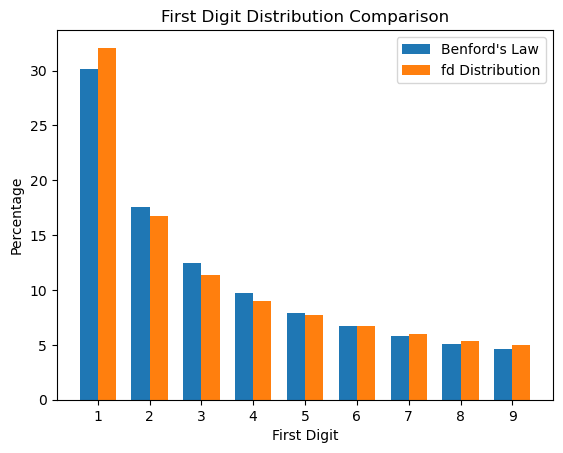

In [38]:
import numpy as np

import matplotlib.pyplot as plt

# Benford's Law distribution
benford_dist = [30.1, 17.6, 12.5, 9.7, 7.9, 6.7, 5.8, 5.1, 4.6]

fd = fd[fd != 0]

# Calculate the distribution of the first digit in fd
fd_dist = fd.value_counts(normalize=True).sort_index() * 100

print(fd_dist)

# Plot the distributions
fig, ax = plt.subplots()
index = np.arange(1, 10)
bar_width = 0.35

rects1 = ax.bar(index, benford_dist, bar_width, label='Benford\'s Law')
rects2 = ax.bar(index + bar_width, fd_dist, bar_width, label='fd Distribution')

ax.set_xlabel('First Digit')
ax.set_ylabel('Percentage')
ax.set_title('First Digit Distribution Comparison')
ax.set_xticks(index + bar_width / 2)
ax.set_xticklabels(index)
ax.legend()

plt.show()

